In [19]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import pickle as pkl
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 한글 폰트 설정 (한글 깨짐 방지)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

df_officetel = pd.read_csv("./officetel_processed_items_data_2026-04-22.csv")

df = df_officetel.dropna(subset=['converted_monthly_rent'])
# 이상치 제거
Q1 = df['converted_monthly_rent'].quantile(0.01)
Q3 = df['converted_monthly_rent'].quantile(0.99)

df = df[(df['converted_monthly_rent'] >= Q1) & (df['converted_monthly_rent'] <= Q3)]
df = df[(df['area_m2'] > 0) & (df['area_m2'] < 200)]
df = df[(df['building_age'] >= 0) & (df['building_age'] < 100)]

X = df.drop('converted_monthly_rent', axis=1).select_dtypes(include=['number'])
y = np.log1p(df['converted_monthly_rent'])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

train_ds = lgb.Dataset(X_train, label=y_train.values.flatten())
val_ds = lgb.Dataset(X_val, label=y_val.values.flatten(), reference=train_ds)

params = {'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'learning_rate': 0.01}
model = lgb.train(
    params, train_ds, num_boost_round=1000,
    valid_sets=[val_ds],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.270699
[200]	valid_0's rmse: 0.216092
[300]	valid_0's rmse: 0.193341
[400]	valid_0's rmse: 0.179602
[500]	valid_0's rmse: 0.170642
[600]	valid_0's rmse: 0.164101
[700]	valid_0's rmse: 0.159441
[800]	valid_0's rmse: 0.155571
[900]	valid_0's rmse: 0.152501
[1000]	valid_0's rmse: 0.150154
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 0.150154


--- 오피스텔 모델 성능 성적표 ---
1. R2-Score (결정계수): 0.8688
2. 원룸 평균 오차: 약 11.95만 원
3. RMSE (제곱근평균제곱오차): 18.17 만원


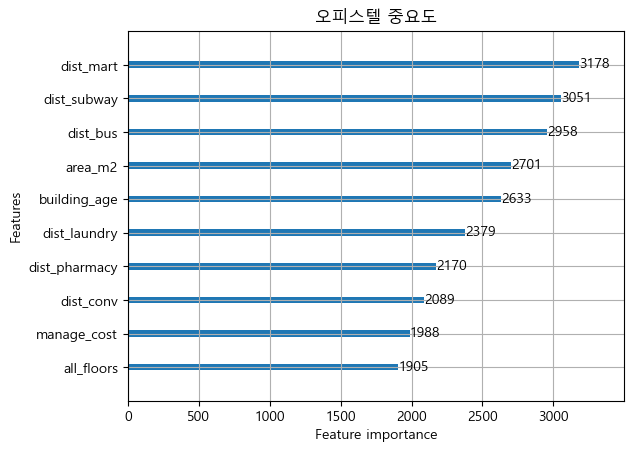

In [24]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)
    
print(f"--- 오피스텔 모델 성능 성적표 ---")
print(f"1. R2-Score (결정계수): {r2_score(y_true, y_pred):.4f}")    
mae = np.mean(np.abs(y_true - y_pred))
print(f"2. 원룸 평균 오차: 약 {round(mae, 2)}만 원")
print(f"3. RMSE (제곱근평균제곱오차): {np.sqrt(mean_squared_error(y_true, y_pred)):.2f} 만원")
    
lgb.plot_importance(model, max_num_features=10, title=f"오피스텔 중요도")
plt.show()


In [22]:
model.save_model('lgbm_officetel_model.txt')

In [23]:
with open('lgbm_officetel_model.pkl', 'wb') as f:
    pkl.dump(model, f)